In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [5]:
#Load Dataset
df = pd.read_excel("Data/ecommerce_project.xlsx", sheet_name="Sales_Data")

df.head()

,Order_ID,Date,Customer,Region,Category,Product,Quantity,Unit_Price,Total_Sales,Profit
0,ORD001,2025-06-26,Customer_1,South,Electronics,Headphones,5,293,1465,287.75
1,ORD002,2025-10-23,Customer_19,West,Electronics,Laptop,1,92,92,30.86
2,ORD003,2025-05-22,Customer_29,East,Home,Chair,1,403,403,43.96
3,ORD004,2025-08-21,Customer_11,South,Books,Comics,4,493,1972,256.94
4,ORD005,2025-04-10,Customer_1,West,Electronics,Phone,4,428,1712,535.77


In [7]:
# Dataset Overview
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()


Rows: 100
Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     100 non-null    object 
 1   Date         100 non-null    object 
 2   Customer     100 non-null    object 
 3   Region       100 non-null    object 
 4   Category     100 non-null    object 
 5   Product      100 non-null    object 
 6   Quantity     100 non-null    int64  
 7   Unit_Price   100 non-null    int64  
 8   Total_Sales  100 non-null    int64  
 9   Profit       100 non-null    float64
dtypes: float64(1), int64(3), object(6)
memory usage: 7.9+ KB


In [9]:
# Missing Values
df.isnull().sum()

Order_ID       0
Date           0
Customer       0
Region         0
Category       0
Product        0
Quantity       0
Unit_Price     0
Total_Sales    0
Profit         0
dtype: int64

In [10]:
# Descriptive Statistics
df.describe()

,Quantity,Unit_Price,Total_Sales,Profit
count,100.000000,100.000000,100.000000,100.000000
mean,3.020000,245.200000,728.220000,147.789000
std,1.483784,141.824119,579.607523,143.144074
min,1.000000,15.000000,22.000000,3.700000
25%,2.000000,106.500000,245.250000,36.652500
50%,3.000000,271.000000,592.500000,95.200000
75%,4.000000,357.000000,1213.750000,218.817500
max,5.000000,493.000000,2200.000000,603.750000


In [11]:
# KPI Analysis

total_sales = df["Total_Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
avg_order_value = df["Total_Sales"].mean()

print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))

Total Sales: 72822
Total Profit: 14778.9
Total Orders: 100
Average Order Value: 728.22


In [12]:
# Sales by Category

category_sales = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Books          18975
Electronics    18918
Home           17542
Clothing       17387
Name: Total_Sales, dtype: int64

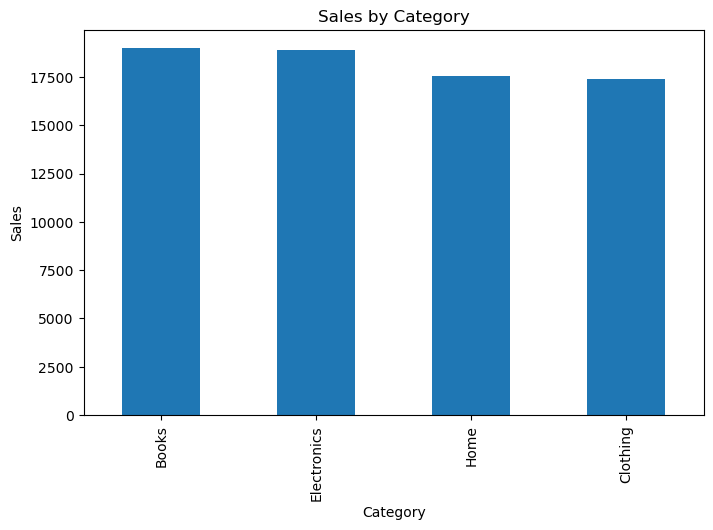

In [14]:
# Category Visualization

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.xlabel("Category")

plt.show()

In [15]:
# Sales by Region
region_sales = (
    df.groupby("Region")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
South    22974
West     20696
East     18916
North    10236
Name: Total_Sales, dtype: int64

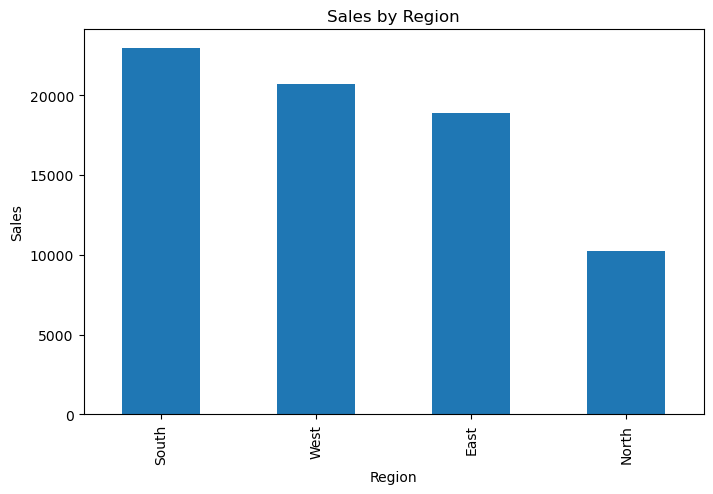

In [16]:
# Region Chart
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.ylabel("Sales")

plt.show()


In [17]:
# Top 10 Products
top_products = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product
Comics        9930
Laptop        7771
Jeans         7072
Lamp          6820
Education     6044
Phone         5731
Jacket        5532
Headphones    5416
Chair         5368
Mixer         5354
Name: Total_Sales, dtype: int64

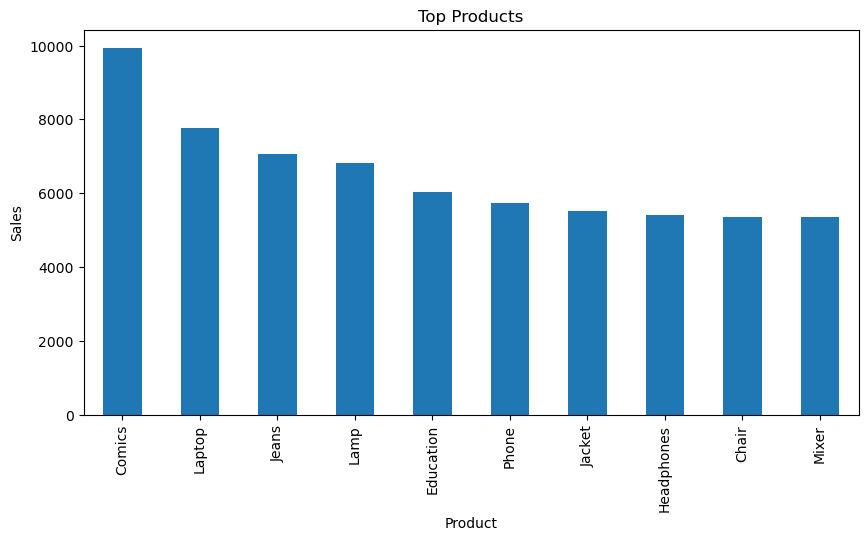

In [18]:
#op Product Chart
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top Products")
plt.ylabel("Sales")

plt.show()

In [19]:
#Customer Segmentation

df["Customer Segment"] = np.where(
    df["Total_Sales"] >= 1000,
    "High Value",
    np.where(
        df["Total_Sales"] >= 500,
        "Medium Value",
        "Low Value"
    )
)

df.head()

,Order_ID,Date,Customer,Region,Category,Product,Quantity,Unit_Price,Total_Sales,Profit,Customer Segment
0,ORD001,2025-06-26,Customer_1,South,Electronics,Headphones,5,293,1465,287.75,High Value
1,ORD002,2025-10-23,Customer_19,West,Electronics,Laptop,1,92,92,30.86,Low Value
2,ORD003,2025-05-22,Customer_29,East,Home,Chair,1,403,403,43.96,Low Value
3,ORD004,2025-08-21,Customer_11,South,Books,Comics,4,493,1972,256.94,High Value
4,ORD005,2025-04-10,Customer_1,West,Electronics,Phone,4,428,1712,535.77,High Value


In [20]:
#Segment Distribution
segment_count = df["Customer Segment"].value_counts()

segment_count

Low Value       46
High Value      29
Medium Value    25
Name: Customer Segment, dtype: int64

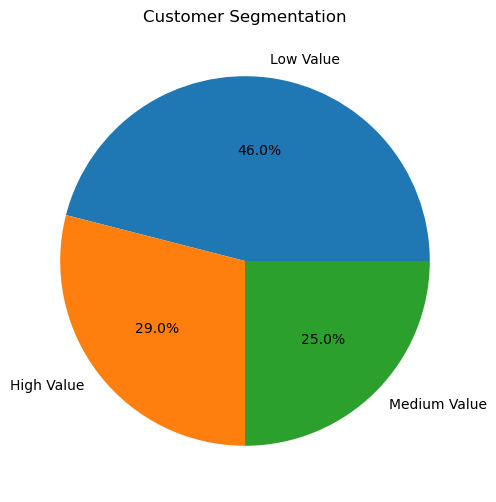

In [21]:
# Segment Pie Chart

plt.figure(figsize=(6,6))

segment_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Customer Segmentation")

plt.show()

In [22]:
#Monthly Sales Trendv

df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = (
    df.groupby(df["Date"].dt.month)["Total_Sales"]
    .sum()
)

monthly_sales

Date
1     4349
2      658
3     7674
4     7978
5     5898
6     9465
7     5682
8     9141
9     7507
10    5411
11    3073
12    5986
Name: Total_Sales, dtype: int64

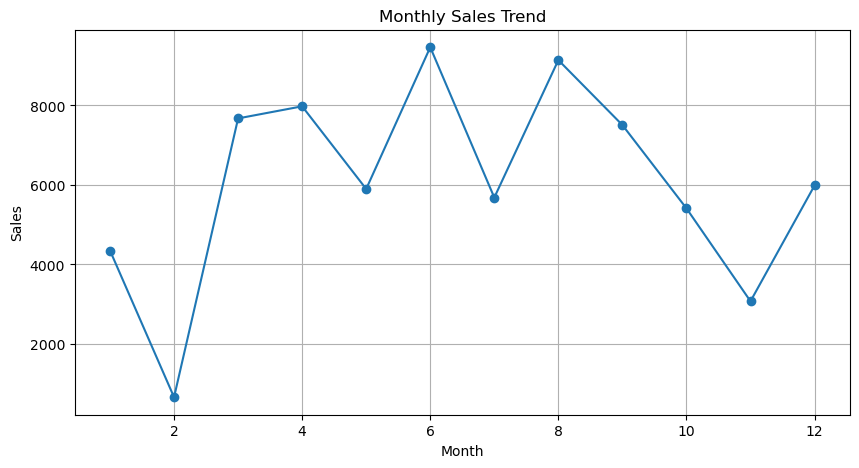

In [23]:
#Monthly Trend Chart
plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Month")

plt.grid(True)

plt.show()

In [24]:
# Business Insights

print("=== BUSINESS INSIGHTS ===")

print()

print("1. Best Category:")
print(category_sales.idxmax())

print()

print("2. Best Region:")
print(region_sales.idxmax())

print()

print("3. Top Product:")
print(top_products.index[0])

print()

print("4. Total Revenue:")
print(round(total_sales,2))

print()

print("5. Total Profit:")
print(round(total_profit,2))

=== BUSINESS INSIGHTS ===

1. Best Category:
Books

2. Best Region:
South

3. Top Product:
Comics

4. Total Revenue:
72822

5. Total Profit:
14778.9


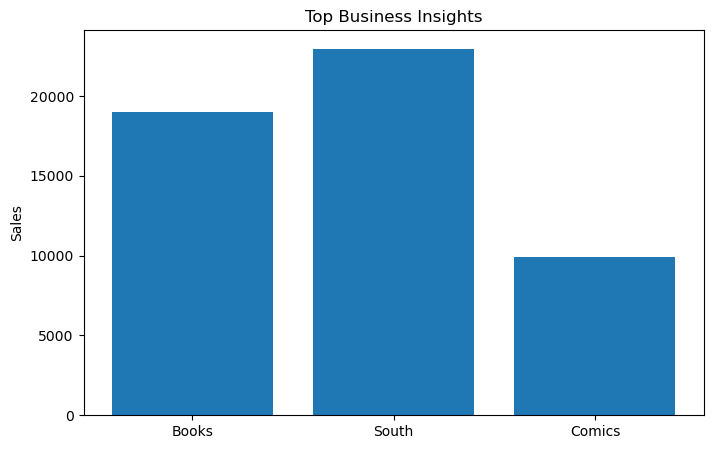

In [25]:
summary = {
    "Books": category_sales["Books"],
    "South": region_sales["South"],
    "Comics": top_products["Comics"]
}

plt.figure(figsize=(8,5))
plt.bar(summary.keys(), summary.values())

plt.title("Top Business Insights")
plt.ylabel("Sales")

plt.show()

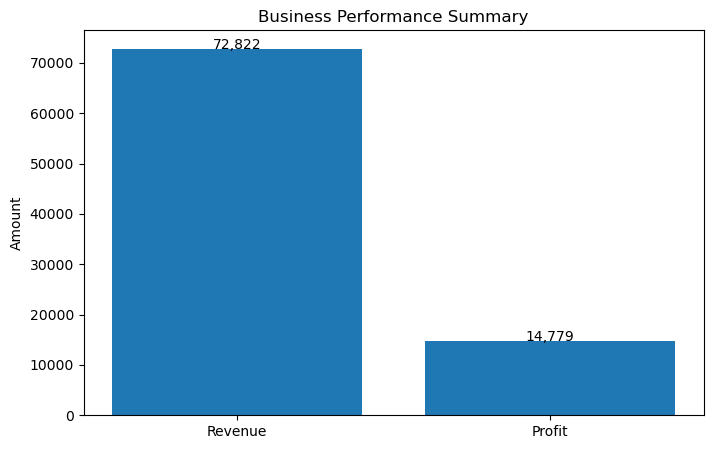

In [26]:
import matplotlib.pyplot as plt

metrics = ['Revenue', 'Profit']
values = [72822, 14778.9]

plt.figure(figsize=(8,5))

bars = plt.bar(metrics, values)

plt.title("Business Performance Summary")
plt.ylabel("Amount")

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center'
    )

plt.show()